<a href="https://colab.research.google.com/github/iam-ansuman/analyze-titanic-dataset-ML/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import the pacakges
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# load the datasets
titanic = sns.load_dataset("titanic")
# Dislay the first 5 rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# checking for the missing values and data types
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


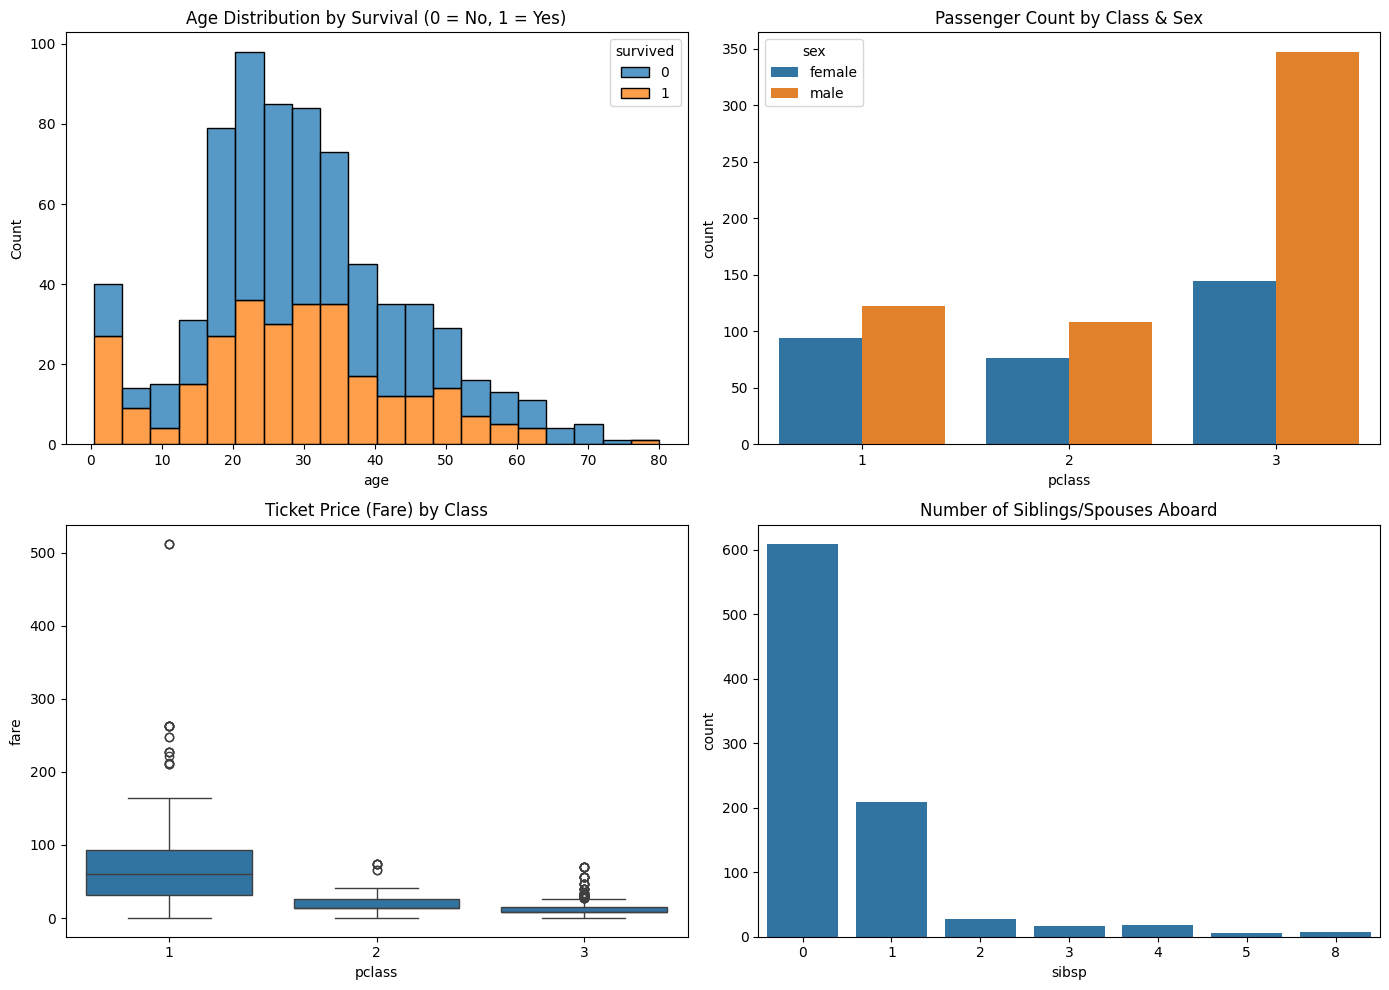

In [ ]:
# Set up a 2x2 grid for our charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 & 8: Age and Survival Correlation
sns.histplot(data=titanic, x='age', hue='survived', multiple='stack', ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Survival (0 = No, 1 = Yes)')

# 3 & 4: Class and Sex Distribution
sns.countplot(data=titanic, x='pclass', hue='sex', ax=axes[0,1])
axes[0,1].set_title('Passenger Count by Class & Sex')

# 7: Prices (Fare) per Class
sns.boxplot(data=titanic, x='pclass', y='fare', ax=axes[1,0])
axes[1,0].set_title('Ticket Price (Fare) by Class')

# 2: Family on Board (Siblings/Spouses)
sns.countplot(data=titanic, x='sibsp', ax=axes[1,1])
axes[1,1].set_title('Number of Siblings/Spouses Aboard')

plt.tight_layout()
plt.show()

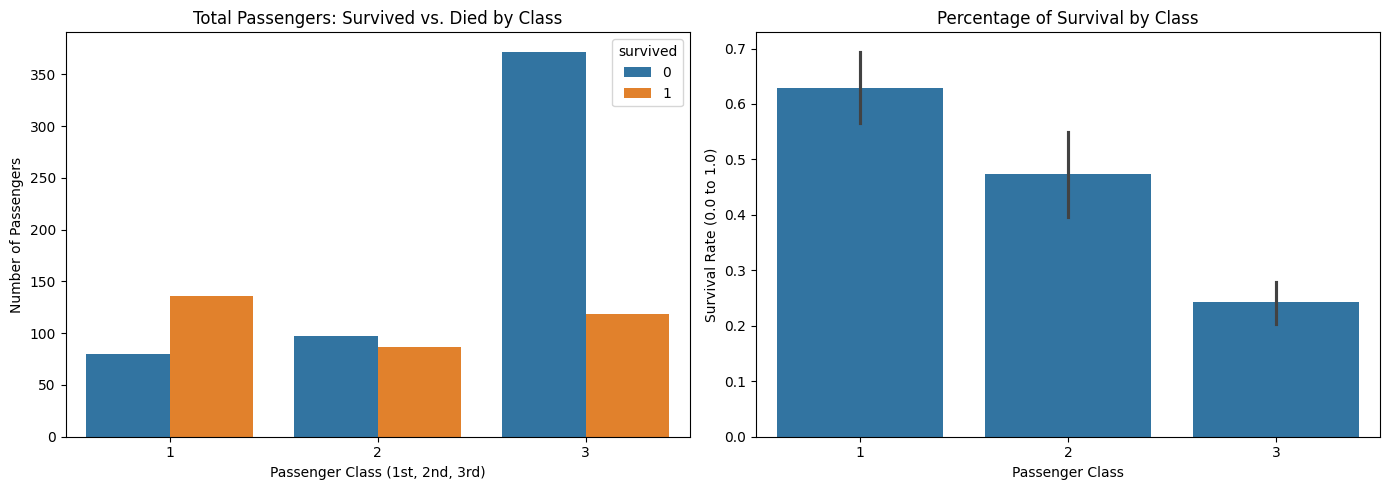

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Raw count of survivors vs non-survivors per class
sns.countplot(data=titanic, x='pclass', hue='survived', ax=axes[0])
axes[0].set_title('Total Passengers: Survived vs. Died by Class')
axes[0].set_xlabel('Passenger Class (1st, 2nd, 3rd)')
axes[0].set_ylabel('Number of Passengers')

# Chart 2: The actual survival percentage rate per class
sns.barplot(data=titanic, x='pclass', y='survived', ax=axes[1])
axes[1].set_title('Percentage of Survival by Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (0.0 to 1.0)')

plt.tight_layout()
plt.show()

In [10]:
# import Requried Libraries
from sklearn.model_selection import train_test_split

# These are the tools we will use next to build our pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier



In [11]:
# 3. Define  target (y) and features (X)
# target : what we want to predict
y = titanic["survived"]
# features : the clues we will use
feature_columns = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = titanic[feature_columns]
